In [8]:
import os
import pandas as pd

# The 'path' variable is not defined, but 'train.csv' is available in /content/
train_file_path = '/content/train.csv'

# Load the dataset
df = pd.read_csv(train_file_path)

# Look at the first 5 rows to see our 'Context' IDs
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (32769, 10)


,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


Step 1: Calculate the Peer Similarity Score


In [9]:
# 1. Group by Department and Resource to see how many people have what
peer_counts = df.groupby(['ROLE_DEPTNAME', 'RESOURCE']).size().reset_index(name='access_count')

# 2. Get total number of people in each department
dept_totals = df.groupby('ROLE_DEPTNAME').size().reset_index(name='total_in_dept')

# 3. Merge and calculate the 'Similarity Score' (0.0 to 1.0)
similarity_df = pd.merge(peer_counts, dept_totals, on='ROLE_DEPTNAME')
similarity_df['peer_similarity'] = similarity_df['access_count'] / similarity_df['total_in_dept']

# 4. Map this score back to our main data
df = pd.merge(df, similarity_df[['ROLE_DEPTNAME', 'RESOURCE', 'peer_similarity']],
              on=['ROLE_DEPTNAME', 'RESOURCE'], how='left')

# Show the results!
print("New Column 'peer_similarity' added!")
df[['ROLE_DEPTNAME', 'RESOURCE', 'peer_similarity', 'ACTION']].head(10)

New Column 'peer_similarity' added!


,ROLE_DEPTNAME,RESOURCE,peer_similarity,ACTION
0,123472,39353,0.013889,1
1,123125,17183,0.006289,1
2,117884,36724,0.003663,1
3,119993,36135,0.005263,1
4,119569,42680,0.044444,1
5,118008,45333,0.005587,0
6,123476,25993,0.125000,1
7,118910,19666,0.003077,1
8,120584,31246,0.023810,1
9,117878,78766,0.010573,1


Step 2: Spotting the "Conflict": To find instances where a "High Risk" item was actually approved in the past. This is where security gaps usually hide!

In [10]:
# Find items where similarity is very low (< 5%) but the action was 'Approved' (1)
risky_approvals = df[(df['peer_similarity'] < 0.05) & (df['ACTION'] == 1)]

print(f"Found {len(risky_approvals)} potentially risky approvals that your AI will now flag.")
risky_approvals.head()

Found 25200 potentially risky approvals that your AI will now flag.


,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE,peer_similarity
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908,0.013889
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539,0.006289
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880,0.003663
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322,0.005263
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325,0.044444


Step 3:Installing and training CatBoost for classification


In [11]:
!pip install catboost
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

# 1. Define Features and Target
# We use our new 'peer_similarity' plus the original role columns
features = ['RESOURCE', 'MGR_ID', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'peer_similarity']
X = df[features]
y = df['ACTION']

# 2. Split data: 80% to train the AI, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Identify categorical columns (except our similarity score)
cat_features = ['RESOURCE', 'MGR_ID', 'ROLE_DEPTNAME', 'ROLE_TITLE']

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


Step 4: Train the "Risk Predictor"

In [12]:
# Initialize CatBoost
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=100
)

# Train the model
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

print("Model Training Complete!")

0:	learn: 0.5775970	test: 0.5768719	best: 0.5768719 (0)	total: 153ms	remaining: 1m 16s
100:	learn: 0.1545074	test: 0.1392944	best: 0.1392928 (99)	total: 4.95s	remaining: 19.5s
200:	learn: 0.1451109	test: 0.1372744	best: 0.1372696 (186)	total: 8.04s	remaining: 12s
300:	learn: 0.1374233	test: 0.1373473	best: 0.1369963 (212)	total: 11.8s	remaining: 7.79s
400:	learn: 0.1303404	test: 0.1376818	best: 0.1369963 (212)	total: 19.8s	remaining: 4.88s
499:	learn: 0.1247217	test: 0.1386352	best: 0.1369963 (212)	total: 24.9s	remaining: 0us

bestTest = 0.1369962719
bestIteration = 212

Shrink model to first 213 iterations.
Model Training Complete!


Step 5: Generate Recommendations (The Smart Reviewer Logic)
We’ll take the model's predictions and categorize them into a clear action plan.

In [13]:
import numpy as np

# 1. Get the probability of approval (the 'confidence' of the AI)
y_proba = model.predict_proba(X_test)[:, 1]

# 2. Create a clean DataFrame for the "Manager's View"
reviewer_df = X_test.copy()
reviewer_df['Actual_Status'] = y_test.values
reviewer_df['AI_Confidence_Score'] = np.round(y_proba * 100, 2)

# 3. Define the Business Logic
def get_recommendation(score):
    if score >= 90:
        return "✅ Safe for Bulk Approval"
    elif score <= 20:
        return "🚩 FLAG: High Risk Outlier"
    else:
        return "🔍 Standard Manual Review"

reviewer_df['AI_Recommendation'] = reviewer_df['AI_Confidence_Score'].apply(get_recommendation)

# 4. Display the top 15 items
print("--- SMART ACCESS REVIEW DASHBOARD PREVIEW ---")
display(reviewer_df[['ROLE_DEPTNAME', 'ROLE_TITLE', 'RESOURCE', 'AI_Confidence_Score', 'AI_Recommendation']].head(15))

--- SMART ACCESS REVIEW DASHBOARD PREVIEW ---


,ROLE_DEPTNAME,ROLE_TITLE,RESOURCE,AI_Confidence_Score,AI_Recommendation
18245,118783,118451,37793,98.60,✅ Safe for Bulk Approval
9226,123173,119093,40309,99.19,✅ Safe for Bulk Approval
27195,118746,118784,27356,97.61,✅ Safe for Bulk Approval
6478,121305,119351,5173,98.43,✅ Safe for Bulk Approval
4813,120943,118995,77207,79.88,🔍 Standard Manual Review
8489,121639,118451,82641,98.61,✅ Safe for Bulk Approval
6635,118992,118028,43294,77.14,🔍 Standard Manual Review
6535,119924,118321,34924,88.68,🔍 Standard Manual Review
10594,120823,118890,30830,97.65,✅ Safe for Bulk Approval
25339,119742,117905,80175,98.05,✅ Safe for Bulk Approval


Step 2:Explainable AI (SHAP)

--- FEATURE IMPORTANCE (Which factors drive the risk?) ---


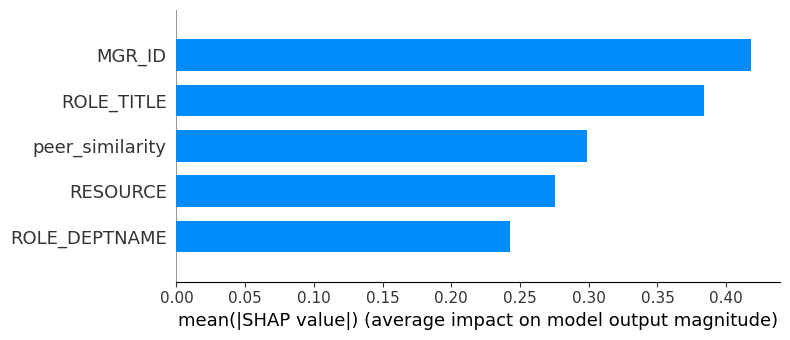

In [14]:
!pip install shap
import shap

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualize the overall feature importance
print("--- FEATURE IMPORTANCE (Which factors drive the risk?) ---")
shap.summary_plot(shap_values, X_test, plot_type="bar")